<a href="https://colab.research.google.com/github/anirbanghoshsbi/.github.io/blob/master/work/indicator/temp/nse_pe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from datetime import date
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
import numpy as np
warnings.filterwarnings("ignore")

In [2]:
data= pd.read_csv("https://raw.githubusercontent.com/anirbanghoshsbi/.github.io/master/work/ml/data_fundamental.csv")

In [3]:
data=data.tail(750)

In [4]:
data.set_index('Date',inplace=True)

In [5]:
#data.set_index('Date',inplace=True)
data['mov50']= data['feat_Div_Yield'].rolling(window=18).mean()
data['price_above_50dma']=data['Close'].rolling(window=50).mean()

In [6]:
data["pe_50dma"] = data["feat_PE"].rolling(50).mean()
data["pe_spread"] = data["feat_PE"] - data["pe_50dma"]
data["dy_pct"] = data["feat_Div_Yield"].rank(pct=True)

In [7]:
data.tail(2)

,feat_PE,feat_PB,feat_Div_Yield,Open,High,Low,Close,mov50,price_above_50dma,pe_50dma,pe_spread,dy_pct
Date,,,,,,,,,,,,
06-Mar-2026,21.39,3.32,1.28,24656.40,24700.80,24415.75,24450.45,1.228889,25577.3892,22.3092,-0.9192,0.422000
09-Mar-2026,21.02,3.27,1.30,23868.05,24078.15,23697.80,24028.05,1.232222,25535.1082,22.2744,-1.2544,0.546667


In [8]:
#data[['feat_Div_Yield','feat_PB','feat_PE','Open','High','Low','Close']].to_csv('data_fundamental.csv')

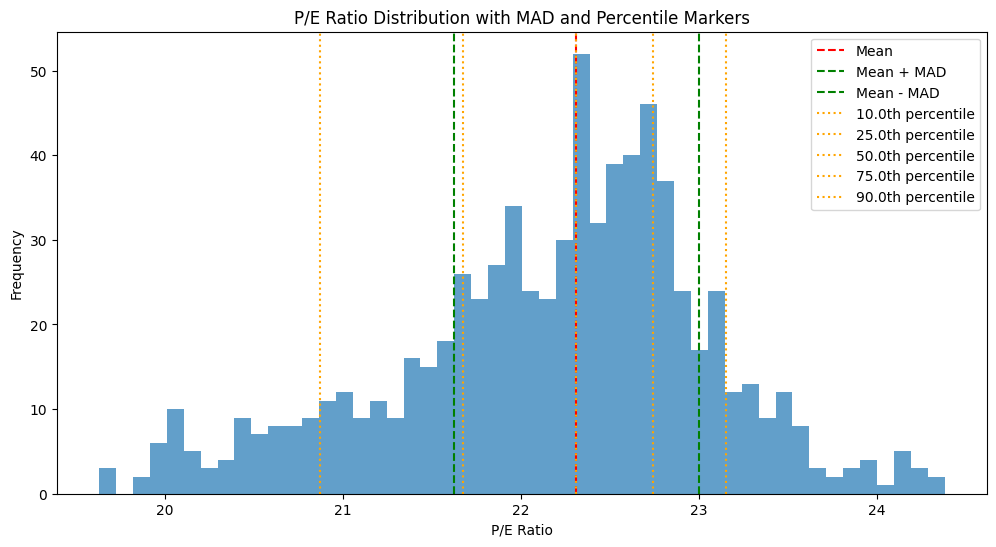

Mean P/E: 22.31
MAD: 0.69
Percentiles:
0.10    20.8700
0.25    21.6725
0.50    22.3100
0.75    22.7400
0.90    23.1500
Name: feat_PE, dtype: float64

Current P/E: 21.02
MAD Score: -1.87 MADs from mean
Percentile Score: 12.13th percentile


In [9]:
# Assume 'pe_ratios' is your time series of P/E ratios
pe_ratios = data['feat_PE']

# Calculate mean and MAD
mean_pe = pe_ratios.median()
mad_pe = (pe_ratios - mean_pe).abs().mean()

# Calculate percentiles
percentiles = pe_ratios.quantile([0.1, 0.25, 0.5, 0.75, 0.9])
data['percentile']=percentiles
# Plot
plt.figure(figsize=(12, 6))
plt.hist(pe_ratios, bins=50, alpha=0.7)
plt.axvline(mean_pe, color='r', linestyle='dashed', label='Mean')
plt.axvline(mean_pe + mad_pe, color='g', linestyle='dashed', label='Mean + MAD')
plt.axvline(mean_pe - mad_pe, color='g', linestyle='dashed', label='Mean - MAD')

for p, v in percentiles.items():
    plt.axvline(v, color='orange', linestyle=':', label=f'{p*100}th percentile')

plt.title('P/E Ratio Distribution with MAD and Percentile Markers')
plt.xlabel('P/E Ratio')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f"Mean P/E: {mean_pe:.2f}")
print(f"MAD: {mad_pe:.2f}")
print("Percentiles:")
print(percentiles)

# Evaluate current P/E
current_pe = data['feat_PE'].iloc[-1]  # Example current P/E
mad_score = (current_pe - mean_pe) / mad_pe
percentile_score = sum(pe_ratios < current_pe) / len(pe_ratios) * 100

print(f"\nCurrent P/E: {current_pe}")
print(f"MAD Score: {mad_score:.2f} MADs from mean")
print(f"Percentile Score: {percentile_score:.2f}th percentile")

In [10]:

from scipy import stats

# Assuming you have a DataFrame 'df' with 'date' and 'pe' columns
# If not, you can create a sample DataFrame like this:
# df = pd.DataFrame({
#     'date': pd.date_range(start='2020-01-01', periods=100, freq='D'),
#     'pe': np.random.uniform(10, 30, 100)
# })

# Calculate percentile scores
data['pe_percentile'] = stats.percentileofscore(data['feat_PE'], data['feat_PE'], kind='weak')
data['pe_pct_roc'] = (data['pe_percentile'] - data['pe_percentile'].shift(10))
'''
# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(data['pe_percentile'].tail(1200))
plt.title('PE Ratio Percentile Score Over Time')
plt.xlabel('Time')  # You can remove this line if you don't want any x-axis label
plt.ylabel('Percentile Score')
plt.grid(True)

# Remove x-axis ticks and labels
plt.gca().xaxis.set_major_locator(plt.NullLocator())
plt.gca().xaxis.set_minor_locator(plt.NullLocator())

# Add horizontal lines at 20th and 80th percentiles
plt.axhline(y=20, color='r', linestyle='--', label='20th percentile')
plt.axhline(y=80, color='g', linestyle='--', label='80th percentile')

plt.legend()
plt.tight_layout()
plt.show()
'''

"\n# Create the plot\nplt.figure(figsize=(12, 6))\nplt.plot(data['pe_percentile'].tail(1200))\nplt.title('PE Ratio Percentile Score Over Time')\nplt.xlabel('Time')  # You can remove this line if you don't want any x-axis label\nplt.ylabel('Percentile Score')\nplt.grid(True)\n\n# Remove x-axis ticks and labels\nplt.gca().xaxis.set_major_locator(plt.NullLocator())\nplt.gca().xaxis.set_minor_locator(plt.NullLocator())\n\n# Add horizontal lines at 20th and 80th percentiles\nplt.axhline(y=20, color='r', linestyle='--', label='20th percentile')\nplt.axhline(y=80, color='g', linestyle='--', label='80th percentile')\n\nplt.legend()\nplt.tight_layout()\nplt.show()\n"

In [11]:
'''
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'data' is your DataFrame with columns: 'pe_percentile' and 'nifty'
# If it's not, you might need to prepare your data accordingly

# Create the plot with two subplots
fig, (ax1, ax2 , ax3) = plt.subplots(3, 1, figsize=(10,5), sharex=True)

# Plot PE Percentile Score
ax1.plot(data['pe_percentile'].tail(1800))
ax1.set_title('PE Ratio Percentile Score Over Time')
ax1.set_ylabel('Percentile Score')
ax1.grid(True)
ax1.axhline(y=20, color='r', linestyle='--')
ax1.axhline(y=80, color='g', linestyle='--')
ax1.legend()

# Plot Nifty Index
ax2.plot(data['Close'].tail(1800))
ax2.set_title('Nifty Index Over Time')
ax2.set_ylabel('Nifty Index Value')
ax2.grid(True)
ax3.plot(data['pe_pct_roc'].tail(1800))
ax3.set_title('Nifty Index Over Time')
ax3.set_ylabel('PE ROC')
ax3.grid(True)
# Remove x-axis ticks and labels
ax1.xaxis.set_major_locator(plt.NullLocator())
ax1.xaxis.set_minor_locator(plt.NullLocator())
ax2.xaxis.set_major_locator(plt.NullLocator())
ax2.xaxis.set_minor_locator(plt.NullLocator())
ax3.xaxis.set_major_locator(plt.NullLocator())
ax3.xaxis.set_minor_locator(plt.NullLocator())

# Adjust layout and display the plot
plt.tight_layout()
plt.show()
'''

"\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\n# Assuming 'data' is your DataFrame with columns: 'pe_percentile' and 'nifty'\n# If it's not, you might need to prepare your data accordingly\n\n# Create the plot with two subplots\nfig, (ax1, ax2 , ax3) = plt.subplots(3, 1, figsize=(10,5), sharex=True)\n\n# Plot PE Percentile Score\nax1.plot(data['pe_percentile'].tail(1800))\nax1.set_title('PE Ratio Percentile Score Over Time')\nax1.set_ylabel('Percentile Score')\nax1.grid(True)\nax1.axhline(y=20, color='r', linestyle='--')\nax1.axhline(y=80, color='g', linestyle='--')\nax1.legend()\n\n# Plot Nifty Index\nax2.plot(data['Close'].tail(1800))\nax2.set_title('Nifty Index Over Time')\nax2.set_ylabel('Nifty Index Value')\nax2.grid(True)\nax3.plot(data['pe_pct_roc'].tail(1800))\nax3.set_title('Nifty Index Over Time')\nax3.set_ylabel('PE ROC')\nax3.grid(True)\n# Remove x-axis ticks and labels\nax1.xaxis.set_major_locator(plt.NullLocator())\nax1.xaxis.set_minor_locator(plt.NullLocator(

In [12]:
'''
# Create the plot with two subplots
fig, (ax1, ax2 ) = plt.subplots(2, 1, figsize=(10,5), sharex=True)



# Plot Nifty Index
ax1.plot(data['Close'].tail(1800))
ax1.set_title('Nifty Index Over Time')
ax1.set_ylabel('Nifty Index Value')
ax1.grid(True)
ax2.plot(data['pe_pct_roc'].tail(1800))
ax2.set_title('Nifty Index Over Time')
ax2.set_ylabel('PE ROC')
ax2.grid(True)
# Remove x-axis ticks and labels
ax1.xaxis.set_major_locator(plt.NullLocator())
ax1.xaxis.set_minor_locator(plt.NullLocator())
ax2.xaxis.set_major_locator(plt.NullLocator())
ax2.xaxis.set_minor_locator(plt.NullLocator())

# Adjust layout and display the plot
plt.tight_layout()
plt.show()
'''

"\n# Create the plot with two subplots\nfig, (ax1, ax2 ) = plt.subplots(2, 1, figsize=(10,5), sharex=True)\n\n\n\n# Plot Nifty Index\nax1.plot(data['Close'].tail(1800))\nax1.set_title('Nifty Index Over Time')\nax1.set_ylabel('Nifty Index Value')\nax1.grid(True)\nax2.plot(data['pe_pct_roc'].tail(1800))\nax2.set_title('Nifty Index Over Time')\nax2.set_ylabel('PE ROC')\nax2.grid(True)\n# Remove x-axis ticks and labels\nax1.xaxis.set_major_locator(plt.NullLocator())\nax1.xaxis.set_minor_locator(plt.NullLocator())\nax2.xaxis.set_major_locator(plt.NullLocator())\nax2.xaxis.set_minor_locator(plt.NullLocator())\n\n# Adjust layout and display the plot\nplt.tight_layout()\nplt.show()\n"

In [13]:
data.shape

(750, 15)

In [14]:
#data=data.tail(1200)

In [15]:
data.shape

(750, 15)

In [16]:
'''
# Create subplots
fig, axs = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
axs[1].axhline(y=1.4,color='g');
axs[1].axhline(y=1.3,color='r');
# Plot 'Close'
axs[0].plot(data['Close'], color='b')
axs[0].set_ylabel('Close')

# Plot 'Div Yield'
axs[1].plot( data['feat_Div_Yield'],  color='g')
axs[1].set_ylabel('feat_Div_Yield')
axs[1].plot(data['mov50'],color='y')
axs[1].invert_yaxis()
# Format date on x-axis to show only month and year
date_format = mdates.DateFormatter('%Y')
axs[1].xaxis.set_major_formatter(date_format)

# Display the plot
plt.tight_layout()
plt.show()
'''

"\n# Create subplots\nfig, axs = plt.subplots(2, 1, figsize=(10, 4), sharex=True)\naxs[1].axhline(y=1.4,color='g');\naxs[1].axhline(y=1.3,color='r');\n# Plot 'Close'\naxs[0].plot(data['Close'], color='b')\naxs[0].set_ylabel('Close')\n\n# Plot 'Div Yield'\naxs[1].plot( data['feat_Div_Yield'],  color='g')\naxs[1].set_ylabel('feat_Div_Yield')\naxs[1].plot(data['mov50'],color='y')\naxs[1].invert_yaxis()\n# Format date on x-axis to show only month and year\ndate_format = mdates.DateFormatter('%Y')\naxs[1].xaxis.set_major_formatter(date_format)\n\n# Display the plot\nplt.tight_layout()\nplt.show()\n"

In [17]:
'''
# Create subplots
fig, axs = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
# Plot 'Close'
axs[0].plot(data['Close'], color='b')
axs[0].set_ylabel('Close')

# Plot 'Div Yield'
axs[1].plot( data['feat_PE'],  color='k')
axs[1].set_ylabel('feat_PE')
axs[1].plot(data['feat_PE'].rolling(window=50).mean(),color='y')
axs[0].plot(data['Close'].rolling(window=50).mean(),color='y')
#axs[1].invert_yaxis()
# Format date on x-axis to show only month and year
date_format = mdates.DateFormatter('%Y')
axs[1].xaxis.set_major_formatter(date_format)

# Display the plot
plt.tight_layout()
plt.show()
'''

"\n# Create subplots\nfig, axs = plt.subplots(2, 1, figsize=(10, 4), sharex=True)\n# Plot 'Close'\naxs[0].plot(data['Close'], color='b')\naxs[0].set_ylabel('Close')\n\n# Plot 'Div Yield'\naxs[1].plot( data['feat_PE'],  color='k')\naxs[1].set_ylabel('feat_PE')\naxs[1].plot(data['feat_PE'].rolling(window=50).mean(),color='y')\naxs[0].plot(data['Close'].rolling(window=50).mean(),color='y')\n#axs[1].invert_yaxis()\n# Format date on x-axis to show only month and year\ndate_format = mdates.DateFormatter('%Y')\naxs[1].xaxis.set_major_formatter(date_format)\n\n# Display the plot\nplt.tight_layout()\nplt.show()\n"

In [18]:
'''
import matplotlib.pyplot as plt

# Assuming 'data' is a pandas DataFrame already loaded with the necessary columns: 'feat_PE' and 'Close'

# Compute the rolling mean adjustment for 'feat_PE'
adjusted_feat_PE = -1 * (data['feat_PE'].rolling(window=50).mean() - data['feat_PE'])

# Create the subplots
fig, axes = plt.subplots(2, 1, figsize=(10,4),sharex=True)

# Plot the adjusted 'feat_PE' in the first subplot
axes[0].plot(adjusted_feat_PE, label='Adjusted feat_PE', color='blue')
axes[0].axhline(y=0, color='c', linestyle='--', label='0')
axes[0].axhline(y=-1.5, color='g', linestyle='--', label='-1.5')
axes[0].axhline(y=1.35, color='r', linestyle='--', label='1.5')
axes[0].set_title("Adjusted feat_PE")
axes[0].set_xlabel("Index")
axes[0].set_ylabel("Value")
#axes[0].legend()

# Plot 'Close' in the second subplot
axes[1].plot(data['Close'], label='Close', color='green')
axes[1].set_title("Close Prices")
axes[1].set_xlabel("Index")
axes[1].set_ylabel("Price")
axes[1].legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()
'''

'\nimport matplotlib.pyplot as plt\n\n# Assuming \'data\' is a pandas DataFrame already loaded with the necessary columns: \'feat_PE\' and \'Close\'\n\n# Compute the rolling mean adjustment for \'feat_PE\'\nadjusted_feat_PE = -1 * (data[\'feat_PE\'].rolling(window=50).mean() - data[\'feat_PE\'])\n\n# Create the subplots\nfig, axes = plt.subplots(2, 1, figsize=(10,4),sharex=True)\n\n# Plot the adjusted \'feat_PE\' in the first subplot\naxes[0].plot(adjusted_feat_PE, label=\'Adjusted feat_PE\', color=\'blue\')\naxes[0].axhline(y=0, color=\'c\', linestyle=\'--\', label=\'0\')\naxes[0].axhline(y=-1.5, color=\'g\', linestyle=\'--\', label=\'-1.5\')\naxes[0].axhline(y=1.35, color=\'r\', linestyle=\'--\', label=\'1.5\')\naxes[0].set_title("Adjusted feat_PE")\naxes[0].set_xlabel("Index")\naxes[0].set_ylabel("Value")\n#axes[0].legend()\n\n# Plot \'Close\' in the second subplot\naxes[1].plot(data[\'Close\'], label=\'Close\', color=\'green\')\naxes[1].set_title("Close Prices")\naxes[1].set_xlabel

In [19]:
data["future_return"] = data["Close"].shift(-20) / data["Close"] - 1

In [20]:
data["target"] = (data["Close"].shift(-20) > data["Close"]).astype(int)

In [21]:
data["pe_bucket"] = pd.qcut(data["feat_Div_Yield"], 5)

print('20 Days Return \n ' ,round(data.groupby("pe_bucket")["future_return"].mean()*100,2))

20 Days Return 
  pe_bucket
(1.0890000000000002, 1.22]    0.18
(1.22, 1.28]                  0.01
(1.28, 1.32]                  1.07
(1.32, 1.38]                  1.36
(1.38, 1.51]                  3.51
Name: future_return, dtype: float64


In [22]:
print('How often the price is higher than 20 days back :\n' ,data.groupby("pe_bucket")["target"].mean())

How often the price is higher than 20 days back :
 pe_bucket
(1.0890000000000002, 1.22]    0.588235
(1.22, 1.28]                  0.450292
(1.28, 1.32]                  0.722689
(1.32, 1.38]                  0.670588
(1.38, 1.51]                  0.891667
Name: target, dtype: float64


In [23]:

high_low = data["High"] - data["Low"]
high_close = (data["High"] - data["Close"].shift()).abs()
low_close = (data["Low"] - data["Close"].shift()).abs()

data["TR"] = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
data["ATR"] = data["TR"].rolling(14).mean()

In [24]:
# --- EMA ---
data["ema13"] = data["Close"].ewm(span=13, adjust=False).mean()

# EMA direction
data["ema13_slope"] = data["ema13"].diff()

# --- MACD ---
ema12 = data["Close"].ewm(span=12, adjust=False).mean()
ema26 = data["Close"].ewm(span=26, adjust=False).mean()

data["macd"] = ema12 - ema26
data["macd_signal"] = data["macd"].ewm(span=9, adjust=False).mean()
data["macd_hist"] = data["macd"] - data["macd_signal"]

# Histogram slope
data["macd_hist_slope"] = data["macd_hist"].diff()

# --- Elder Impulse ---
conditions = [
    (data["ema13_slope"] > 0) & (data["macd_hist_slope"] > 0) & (data['Close'].rolling(window=50).mean()<data['Close']),
    (data["ema13_slope"] < 0) & (data["macd_hist_slope"] < 0) & (data['Close'].rolling(window=50).mean()>data['Close'])
]

choices = [1, -1]   # 1 = Green (Bullish), -1 = Red (Bearish)

data["elder_impulse"] = np.select(conditions, choices, default=0)

# Optional readable label
data["impulse_label"] = data["elder_impulse"].map({
    1: "green",
    -1: "red",
    0: "blue"
})

In [25]:
data.columns

Index(['feat_PE', 'feat_PB', 'feat_Div_Yield', 'Open', 'High', 'Low', 'Close',
       'mov50', 'price_above_50dma', 'pe_50dma', 'pe_spread', 'dy_pct',
       'percentile', 'pe_percentile', 'pe_pct_roc', 'future_return', 'target',
       'pe_bucket', 'TR', 'ATR', 'ema13', 'ema13_slope', 'macd', 'macd_signal',
       'macd_hist', 'macd_hist_slope', 'elder_impulse', 'impulse_label'],
      dtype='object')

## conditional expectancy

If PE percentile is in bucket X AND Elder impulse is green/red → what is the average 10-day forward return?

In [26]:
data["future_return_10"] = data["Close"].shift(-20) / data["Close"] - 1

In [27]:
bins = [0,20,40,60,80,100]
labels = ["20 Percentile","40 Percentile","60 Percentile","80 Percentile", "100 Percentile"]

data["pe_pct_bucket"] = pd.cut(data["pe_percentile"], bins=bins, labels=labels)

In [28]:
result = (
    data
    .groupby(["pe_pct_bucket", "elder_impulse"])["future_return_10"]
    .agg(["mean", 'median' , 'count'])
)

print(result * 100)

                                  mean    median  count
pe_pct_bucket  elder_impulse                           
20 Percentile  -1             2.797847  3.606812   2900
                0             3.328138  3.692122  10300
                1             5.119119  4.448925   1500
40 Percentile  -1             1.191693  1.272283   3300
                0             1.430906  1.517082   8000
                1             3.171153  3.056876   3400
60 Percentile  -1            -0.445756  0.465905   1200
                0             1.164699  1.610164   8000
                1             1.267080  1.103406   5200
80 Percentile  -1             0.376586  1.155640    900
                0             0.066812  0.656670   7800
                1            -0.040928  0.208310   5400
100 Percentile -1            -3.736587 -4.069060    500
                0            -0.932834 -0.784531   7700
                1            -0.324019 -0.633210   6900


In [29]:
data["atr_pct"] = data["ATR"] / data["Close"]
data["vol_adj_return_10"] = data["future_return_10"] / data["atr_pct"]
result = (
    data
    .groupby(["pe_pct_bucket", "elder_impulse"])["vol_adj_return_10"]
    .agg(["mean", "median", "count"])
)

print(result)

                                  mean    median  count
pe_pct_bucket  elder_impulse                           
20 Percentile  -1             2.506819  3.395207     29
                0             4.166928  3.880969     90
                1             5.506155  4.108760     15
40 Percentile  -1             0.678660  0.586731     33
                0             1.752853  1.332181     80
                1             3.648218  2.691648     34
60 Percentile  -1             0.129461  0.583206     12
                0             1.097358  1.498424     80
                1             0.948648  0.743300     52
80 Percentile  -1             0.408366  1.271395      9
                0             0.358573  0.828895     78
                1            -0.182727  0.228706     54
100 Percentile -1            -3.131756 -3.327620      5
                0            -0.955348 -0.745537     77
                1            -0.388913 -0.779033     69


In [30]:
expectancy = data.groupby("elder_impulse")["future_return_10"].agg(
    mean="mean",
    median="median",
    count="count"
)

expectancy = expectancy * [100,100,1]  # convert returns to %
print(expectancy)

                   mean    median  count
elder_impulse                           
-1             1.134326  0.854511     88
 0             1.157487  1.248193    418
 1             1.008602  0.843449    224


In [31]:
data["target10"] = (data["Close"].shift(-20) > data["Close"]).astype(int)

data.groupby("elder_impulse")["target10"].mean()

,target10
elder_impulse,
-1,0.585859
0,0.664303
1,0.635965


<Axes: xlabel='Date'>

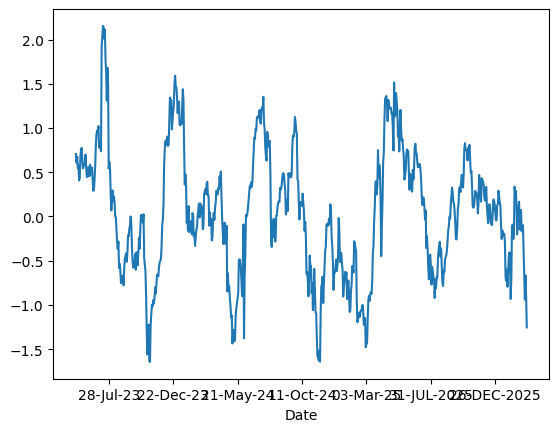

In [32]:
data['pe_spread'].plot()

In [33]:
conditions = [
    (data["dy_pct"] > 0.85) & (data["pe_spread"] < -0.6),
    (data["dy_pct"] > 0.75) & (data["pe_spread"] < -0.4) & (data['elder_impulse']==-1),
    (data["dy_pct"].between(0.25,0.75)) & (data["pe_spread"].diff(5) > 0),
    (data["dy_pct"].between(0.25,0.75)) & (data["pe_spread"].diff(5) < 0),
    (data["dy_pct"] < 0.25) & (data["pe_spread"] > 0.35)
]

choices = ["deep_value","value","uptrend","dntrend","expensive"]

data["valuation_regime"] = np.select(conditions,choices,"neutral")

In [ ]:
data['valuation_regime'].tail(50)

In [37]:
data.loc[data["valuation_regime"] == "deep_value", "valuation_regime"].tail(50)

,valuation_regime
Date,
23-Oct-23,deep_value
25-Oct-23,deep_value
26-Oct-23,deep_value
27-Oct-23,deep_value
30-Oct-23,deep_value
31-Oct-23,deep_value
01-Nov-23,deep_value
02-Nov-23,deep_value
03-Nov-23,deep_value


In [36]:
data.groupby("valuation_regime")["future_return"].mean()*100

,future_return
valuation_regime,
deep_value,3.830429
dntrend,0.705724
expensive,-0.072647
neutral,1.506445
uptrend,0.897847
value,0.709202
